### SEARCH EVALUATION

In [2]:
import pandas as pd

df_ground_truth = pd.read_csv("data/ground_truth-new.csv")
ground_truth = df_ground_truth.to_dict(orient="records")

In [3]:
from ingest import load_faq_data, build_index

documents = load_faq_data()

documents_llm = []

for doc in documents:
    if doc["course"] == "llm-zoomcamp":
        documents_llm.append(doc)

documents = documents_llm
index = build_index(documents)

In [4]:
def text_search(query):
    boost_dict = {"question": 3.0, "section": 0.5}

    return index.search(
        query,
        num_results=5,
        boost_dict=boost_dict
    )

In [12]:
boost={"question": 3.0}

index.search("What is the course about?",
             boost_dict=boost,
             num_results=5
)

[{'id': '04919992b3',
  'course': 'llm-zoomcamp',
  'section': 'General Course-Related Questions',
  'question': 'How should I start the course and follow the weekly workflow?',
  'answer': 'Start with the [LLM Zoomcamp docs](https://datatalks.club/docs/courses/llm-zoomcamp/), the [general Zoomcamp logistics docs](https://datatalks.club/docs/courses/zoomcamp-logistics/), and the [LLM Zoomcamp GitHub repository](https://github.com/DataTalksClub/llm-zoomcamp).\n\nYou can start whenever you want. The videos and GitHub materials are available, and the deadlines are listed in the [course management platform](https://courses.datatalks.club/llm-zoomcamp-2026/).\n\nA typical workflow is:\n\n1. Watch the lesson videos.\n2. Work through the lesson notebooks/code.\n3. Read the homework instructions on GitHub.\n4. Submit answers through the course platform before the deadline.\n\nHomework is similar to the lesson flow, but uses a different dataset or slightly different task.'},
 {'id': 'db78580409

#### Collecting relevance data

In [13]:
q = ground_truth[0]
q

{'question': 'Can I still join the course if I found it late?',
 'document': '74eb249bbf'}

In [14]:
doc_id = q["document"]
results = text_search(query=q["question"])

In [15]:
for d in results:
    print(f'{d["id"]} == {doc_id}: {d["id"] == doc_id}')

74eb249bbf == 74eb249bbf: True
a9353fadfe == 74eb249bbf: False
9f689c185f == 74eb249bbf: False
977bf7786c == 74eb249bbf: False
04919992b3 == 74eb249bbf: False


In [16]:
relevance = []

for d in results:
    relevance.append(int(d["id"] == doc_id))

relevance

[1, 0, 0, 0, 0]

In [17]:
def compute_relevance_text(q):
    doc_id = q["document"]
    results = text_search(query=q["question"])

    relevance = []
    for d in results:
        relevance.append(int(d["id"] == doc_id))

    return relevance

In [18]:
q = ground_truth[0]
print(q["question"])
compute_relevance_text(q)
# [1, 0, 0, 0, 0]

Can I still join the course if I found it late?


[1, 0, 0, 0, 0]

In [19]:
q = ground_truth[11]
print(q["question"])
compute_relevance_text(q)
# [1, 0, 0, 0, 0]

Where do I find the live stream link for Office Hours before it starts?


[1, 0, 0, 0, 0]

In [20]:
q = ground_truth[50]
print(q["question"])
compute_relevance_text(q)
# [1, 0, 0, 0, 0]

Where do I check the LLM Zoomcamp syllabus and homework deadlines?


[1, 0, 0, 0, 0]

In [21]:
from tqdm.auto import tqdm

def compute_relevance_total_text(ground_truth):
    relevance_total = []

    for q in tqdm(ground_truth):
        relevance = compute_relevance_text(q)
        relevance_total.append(relevance)

    return relevance_total

In [22]:
ground_truth_sample = ground_truth[:15]
relevance_total_text = compute_relevance_total_text(ground_truth_sample)

  0%|          | 0/15 [00:00<?, ?it/s]

In [23]:
relevance_total_text

[[1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 1, 0, 0, 0]]

In [24]:
def compute_relevance(q, search_function):
    doc_id = q["document"]
    results = search_function(query=q["question"])

    relevance = []
    for d in results:
        relevance.append(int(d["id"] == doc_id))

    return relevance

In [25]:
def compute_relevance_total(ground_truth, search_function):
    relevance_total = []

    for q in tqdm(ground_truth):
        relevance = compute_relevance(q, search_function)
        relevance_total.append(relevance)

    return relevance_total

In [26]:
relevance_total = compute_relevance_total(ground_truth_sample, text_search)
relevance_total

  0%|          | 0/15 [00:00<?, ?it/s]

[[1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 1, 0, 0, 0]]

In [27]:
relevance_total = compute_relevance_total(ground_truth, text_search)


  0%|          | 0/575 [00:00<?, ?it/s]

In [29]:
relevance_total[:15]

[[1, 0, 0, 0, 0],
 [0, 0, 0, 0, 0],
 [0, 1, 0, 0, 0],
 [0, 0, 0, 1, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 0, 0, 0, 1],
 [0, 0, 1, 0, 0],
 [0, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [1, 0, 0, 0, 0],
 [0, 1, 0, 0, 0]]

#### SEARCH EVALUATION METRICS

Hit Rate (also called Recall@k) measures the fraction of queries where the correct document appears anywhere in the results

In [30]:
example = [
    [1, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [0, 0, 1, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0],
]

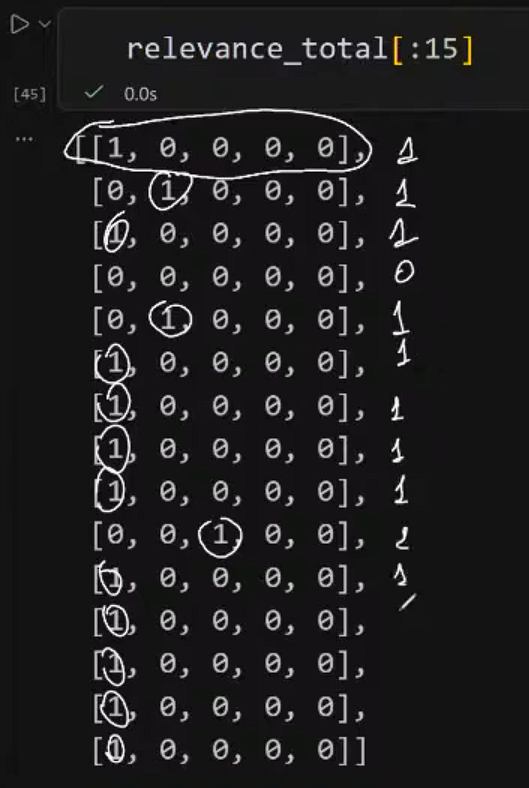

In [31]:
cnt = 0

for line in example:
    if 1 in line:
        cnt = cnt + 1

cnt

14

In [32]:
# HIT RATE

cnt / len(example)
# 0.933

0.9333333333333333

In [33]:
def hit_rate(relevance):
    cnt = 0

    for line in relevance:
        if 1 in line:
            cnt = cnt + 1

    return cnt / len(relevance)

In [34]:
hit_rate(example)
# 0.933

0.9333333333333333

In [35]:
# For dataset
hit_rate(relevance_total)

0.8347826086956521

MEAN RECIPROCAL RANK (MRR)

Hit Rate tells us if we found the right document, but not where it was.

MRR also considers the position.

In [36]:
example[1]
# [0, 1, 0, 0, 0]

[0, 1, 0, 0, 0]

In [37]:
total_score = 0.0

for line in example:
    for rank in range(len(line)):
        if line[rank] == 1:
            total_score = total_score + 1 / (rank + 1)
            break

total_score

12.333333333333332

In [38]:
total_score / len(example)
# 0.822

0.8222222222222222

In [39]:
def mrr(relevance):
    total_score = 0.0

    for line in relevance:
        for rank in range(len(line)):
            if line[rank] == 1:
                total_score = total_score + 1 / (rank + 1)
                break

    return total_score / len(relevance)

In [40]:
mrr(example)
# 0.822

0.8222222222222222

In [41]:
mrr(relevance_total)

0.7192463768115939

In [42]:
def evaluate(ground_truth, search_function):
    relevance_total = compute_relevance_total(ground_truth, search_function)

    return {
        "hit_rate": hit_rate(relevance_total),
        "mrr": mrr(relevance_total),
    }

In [43]:
evaluate(
    ground_truth,
    text_search
)

  0%|          | 0/575 [00:00<?, ?it/s]

{'hit_rate': 0.8347826086956521, 'mrr': 0.7192463768115939}

MRR is a better metric to reflect if your answer is on top or not

In [44]:
def search_boost(query, question_boost):
    boost_dict = {"question": question_boost, "section": 0.5}

    return index.search(
        query,
        num_results=5,
        boost_dict=boost_dict,
    )

In [45]:
for boost in [0.5, 1.0, 3.0, 5.0, 10.0]:
    result = evaluate(
        ground_truth,
        lambda query, boost=boost: search_boost(query, boost)
    )
    print(f"boost={boost}: {result}")

  0%|          | 0/575 [00:00<?, ?it/s]

boost=0.5: {'hit_rate': 0.8956521739130435, 'mrr': 0.8004347826086954}


  0%|          | 0/575 [00:00<?, ?it/s]

boost=1.0: {'hit_rate': 0.8921739130434783, 'mrr': 0.7806666666666663}


  0%|          | 0/575 [00:00<?, ?it/s]

boost=3.0: {'hit_rate': 0.8347826086956521, 'mrr': 0.7192463768115939}


  0%|          | 0/575 [00:00<?, ?it/s]

boost=5.0: {'hit_rate': 0.8, 'mrr': 0.6832463768115941}


  0%|          | 0/575 [00:00<?, ?it/s]

boost=10.0: {'hit_rate': 0.768695652173913, 'mrr': 0.6578260869565216}


In [46]:
def search_boosts(query, question_boost, answer_boost, section_boost):
    boost_dict = {
        "question": question_boost,
        "section": section_boost,
        "answer": answer_boost,
    }

    return index.search(
        query,
        num_results=5,
        boost_dict=boost_dict,
    )

In [47]:
results = []

for question_boost in [1.0, 2.0, 5.0]:
    for answer_boost in [1.0, 2.0, 4.0, 10.0]:
        for section_boost in [0.1, 0.2, 0.5]:
            print(
                f"Evaluating question_boost={question_boost},"
                f" answer_boost={answer_boost},"
                f" section_boost={section_boost}..."
            )
            result = evaluate(
                ground_truth,
                lambda query, question_boost=question_boost, answer_boost=answer_boost, section_boost=section_boost: search_boosts(
                    query,
                    question_boost,
                    answer_boost,
                    section_boost
                )
            )

            results.append({
                "question": question_boost,
                "answer": answer_boost,
                "section": section_boost,
                "hit_rate": result["hit_rate"],
                "mrr": result["mrr"],
            })

Evaluating question_boost=1.0, answer_boost=1.0, section_boost=0.1...


  0%|          | 0/575 [00:00<?, ?it/s]

Evaluating question_boost=1.0, answer_boost=1.0, section_boost=0.2...


  0%|          | 0/575 [00:00<?, ?it/s]

Evaluating question_boost=1.0, answer_boost=1.0, section_boost=0.5...


...

  0%|          | 0/575 [00:00<?, ?it/s]

Evaluating question_boost=5.0, answer_boost=10.0, section_boost=0.2...


  0%|          | 0/575 [00:00<?, ?it/s]

Evaluating question_boost=5.0, answer_boost=10.0, section_boost=0.5...


  0%|          | 0/575 [00:00<?, ?it/s]

In [48]:
df_results = pd.DataFrame(results)
df_results.sort_values("mrr", ascending=False).head(10)

,question,answer,section,hit_rate,mrr
7,1.0,4.0,0.2,0.968696,0.873217
22,2.0,10.0,0.2,0.963478,0.872841
6,1.0,4.0,0.1,0.966957,0.872696
23,2.0,10.0,0.5,0.963478,0.871333
4,1.0,2.0,0.2,0.960000,0.868841
21,2.0,10.0,0.1,0.963478,0.868783
35,5.0,10.0,0.5,0.961739,0.868551
3,1.0,2.0,0.1,0.961739,0.868551
19,2.0,4.0,0.2,0.961739,0.868551
8,1.0,4.0,0.5,0.961739,0.867768


In [49]:
def text_search(query):
    boost_dict = {
        "question": 1.0,
        "answer": 4.0,
        "section": 0.2,
    }

    return index.search(
        query,
        num_results=5,
        boost_dict=boost_dict,
    )

Instead of doing grid search you can use Hyperopt -> Optimizers designed to choose best parameters.

For text search on our dataset, grid search takes about one second per combination. That makes it practical to try many options. When each evaluation takes minutes instead of seconds, grid search becomes too expensive. In those cases, use Bayesian optimization with a library like hyperopt. It explores the parameter space more efficiently by focusing on combinations that are likely to improve the metric.